In [22]:
import os
import sys
import math
import pickle
import json
import importlib
import subprocess
import hashlib
from datetime import datetime, timezone
from itertools import product
from typing import Any, Dict, List, Optional
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
MAMBA_REQ = "mamba-ssm==2.3.1"
CAUSAL_REQ = "causal-conv1d==1.6.1"
EINOPS_REQ = "einops>=0.7"

# Keep this False for normal runs. Set True only once if your env is missing packages.
AUTO_INSTALL_MAMBA_IN_ENV = False


def _module_exists(module_name: str) -> bool:
    try:
        return importlib.util.find_spec(module_name) is not None
    except Exception:
        return False


def _safe_import_version(module_name: str) -> tuple[bool, str | None, str | None]:
    """Return (ok, version, error_message) without crashing the cell."""
    try:
        module = importlib.import_module(module_name)
        version = getattr(module, "__version__", "unknown")
        return True, str(version), None
    except Exception as exc:
        return False, None, f"{type(exc).__name__}: {exc}"


print("Python:", sys.executable)
print("CONDA_DEFAULT_ENV:", os.environ.get("CONDA_DEFAULT_ENV", ""))

have_causal = _module_exists("causal_conv1d")
have_mamba = _module_exists("mamba_ssm")

if not (have_causal and have_mamba) and AUTO_INSTALL_MAMBA_IN_ENV:
    print("Installing mamba dependencies into active environment...")
    try:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "pip",
            "setuptools",
            "wheel",
            "ninja",
            EINOPS_REQ,
        ])
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "--no-build-isolation",
            "--upgrade",
            CAUSAL_REQ,
            MAMBA_REQ,
        ])
    except subprocess.CalledProcessError as exc:
        print(f"Auto-install failed: {exc}")

causal_ok, causal_ver, causal_err = _safe_import_version("causal_conv1d")
mamba_ok, mamba_ver, mamba_err = _safe_import_version("mamba_ssm")

print("causal_conv1d:", causal_ver if causal_ok else f"broken ({causal_err})")
print("mamba_ssm:", mamba_ver if mamba_ok else f"broken ({mamba_err})")

if not (causal_ok and mamba_ok):
    print("\nMamba dependencies are missing or broken in this kernel environment.")
else:
    print("Mamba dependencies are ready from the active environment (no per-run install needed).")

Python: /ocean/projects/cis260122p/ccheung1/.conda_envs/lob/bin/python3.11
CONDA_DEFAULT_ENV: /ocean/projects/cis260122p/ccheung1/.conda_envs/lob
causal_conv1d: 1.6.1
mamba_ssm: 2.3.1
Mamba dependencies are ready from the active environment (no per-run install needed).


In [3]:
repo_root = None
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / "src").exists():
        repo_root = candidate.resolve()
        if str(repo_root) not in sys.path:
            sys.path.insert(0, str(repo_root))
        break
if repo_root is None:
    raise RuntimeError("Could not locate project root containing 'src'.")

from src.models import (
    DeepHitMambaCompeting,
    DeepHitRNNCompeting,
    DeepHitRNNTransformerCompeting,
    DeepHitTransformerCompeting,
)

In [4]:
def count_trainable_params(model) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def resolve_fc_hidden(
    hidden_size: int,
    fc_hidden: Optional[int] = None,
    fc_hidden_ratio: float = 1.75,
) -> int:
    if fc_hidden is not None:
        return int(fc_hidden)
    return int(round(hidden_size * fc_hidden_ratio))


def resolve_transformer_ff_dim(
    hidden_size: int,
    ff_ratio: float = 3.0,
) -> int:
    return int(round(hidden_size * ff_ratio))


def fmt_millions(n: int) -> str:
    return f"{n / 1_000_000:.3f}M"

In [5]:
DATASET_BASE_DIR = Path("/ocean/projects/cis260122p/shared/data/datasets")
DATASET_STEM_TEMPLATE = "labeled_dataset_XNAS_ITCH_{ticker}_mbo_20251001_20260101"
TICKER = "AAPL"

stem = DATASET_STEM_TEMPLATE.format(ticker=TICKER)
order_store_path = DATASET_BASE_DIR / f"{stem}_dynamic_order_store.pkl"
runtime_npz_path = DATASET_BASE_DIR / f"{stem}_dynamic_preprocessed.npz"

with open(order_store_path, "rb") as f:
    ORDER_STORE = pickle.load(f)

with np.load(runtime_npz_path, allow_pickle=False) as data:
    time_grid = data["time_grid"]

NUM_FEATURES = int(ORDER_STORE.lob_dim + ORDER_STORE.tox_dim + 2)
NUM_EVENTS = 2
NUM_TIME_STEPS = int(time_grid.shape[0])
MAX_SEQ_LEN = int(ORDER_STORE.lookback_steps)

print(NUM_FEATURES, NUM_EVENTS, NUM_TIME_STEPS, MAX_SEQ_LEN)

34 2 30 500


In [6]:
def build_model_from_config(cfg: Dict[str, Any]):
    model_name = cfg["model_name"]
    hidden_size = int(cfg["hidden_size"])
    fc_hidden = resolve_fc_hidden(
        hidden_size=hidden_size,
        fc_hidden=cfg.get("fc_hidden"),
        fc_hidden_ratio=cfg.get("fc_hidden_ratio", 1.75),
    )

    if model_name == "gru":
        return DeepHitRNNCompeting(
            num_features=NUM_FEATURES,
            num_events=NUM_EVENTS,
            num_time_steps=NUM_TIME_STEPS,
            hidden_size=hidden_size,
            num_layers=int(cfg["gru_layers"]),
            rnn_dropout=float(cfg.get("rnn_dropout", 0.2)),
            fc_hidden=fc_hidden,
            fc_dropout=float(cfg.get("fc_dropout", 0.2)),
        )

    elif model_name == "transformer":
        num_heads = int(cfg.get("transformer_heads", 4))
        if hidden_size % num_heads != 0:
            raise ValueError(
                f"Transformer hidden_size={hidden_size} must be divisible by num_heads={num_heads}"
            )

        return DeepHitTransformerCompeting(
            num_features=NUM_FEATURES,
            num_events=NUM_EVENTS,
            num_time_steps=NUM_TIME_STEPS,
            hidden_size=hidden_size,
            num_layers=int(cfg["transformer_layers"]),
            num_heads=num_heads,
            transformer_ff_dim=resolve_transformer_ff_dim(
                hidden_size, float(cfg.get("transformer_ff_ratio", 3.0))
            ),
            transformer_dropout=float(cfg.get("transformer_dropout", 0.1)),
            max_seq_len=int(cfg.get("max_seq_len", MAX_SEQ_LEN)),
            fc_hidden=fc_hidden,
            fc_dropout=float(cfg.get("fc_dropout", 0.2)),
        )

    elif model_name == "gru_transformer":
        num_heads = int(cfg.get("transformer_heads", 4))
        if hidden_size % num_heads != 0:
            raise ValueError(
                f"GRU+Transformer hidden_size={hidden_size} must be divisible by transformer_heads={num_heads}"
            )

        return DeepHitRNNTransformerCompeting(
            num_features=NUM_FEATURES,
            num_events=NUM_EVENTS,
            num_time_steps=NUM_TIME_STEPS,
            hidden_size=hidden_size,
            num_layers=int(cfg["gru_layers"]),
            rnn_dropout=float(cfg.get("rnn_dropout", 0.2)),
            transformer_layers=int(cfg["transformer_layers"]),
            transformer_heads=num_heads,
            transformer_ff_dim=resolve_transformer_ff_dim(
                hidden_size, float(cfg.get("transformer_ff_ratio", 3.0))
            ),
            transformer_dropout=float(cfg.get("transformer_dropout", 0.1)),
            max_seq_len=int(cfg.get("max_seq_len", MAX_SEQ_LEN)),
            fc_hidden=fc_hidden,
            fc_dropout=float(cfg.get("fc_dropout", 0.2)),
        )

    elif model_name == "mamba":
        return DeepHitMambaCompeting(
            num_features=NUM_FEATURES,
            num_events=NUM_EVENTS,
            num_time_steps=NUM_TIME_STEPS,
            hidden_size=hidden_size,
            num_mamba_layers=int(cfg["mamba_layers"]),
            d_state=int(cfg.get("mamba_d_state", 16)),
            d_conv=int(cfg.get("mamba_d_conv", 4)),
            expand=int(cfg.get("mamba_expand", 2)),
            mamba_dropout=float(cfg.get("mamba_dropout", 0.15)),
            fc_hidden=fc_hidden,
            fc_dropout=float(cfg.get("fc_dropout", 0.2)),
        )

    else:
        raise ValueError(f"Unsupported model_name={model_name}")

In [7]:
SEARCH_SPACE = {
    "shared": {
        "fc_hidden_ratio": [1.75],      # keep fixed initially
        "fc_dropout": [0.2],
    },

    "gru": {
        "hidden_size": [96, 128, 160, 192, 224],
        "gru_layers": [1, 2, 3],
        "rnn_dropout": [0.2],
    },

    "transformer": {
        "hidden_size": [64, 96, 128, 160, 192],
        "transformer_layers": [1, 2, 4],
        "transformer_heads": [4],
        "transformer_ff_ratio": [3.0],
        "transformer_dropout": [0.1],
    },

    "gru_transformer": {
        "hidden_size": [64, 96, 128, 160],
        "gru_layers": [1, 2],
        "transformer_layers": [1, 2],
        "transformer_heads": [4],
        "transformer_ff_ratio": [3.0],
        "rnn_dropout": [0.2],
        "transformer_dropout": [0.1],
    },

    "mamba": {
        "hidden_size": [96, 128, 144, 160, 192, 224],
        "mamba_layers": [1, 2, 4],
        "mamba_d_state": [16],
        "mamba_d_conv": [4],
        "mamba_expand": [2],
        "mamba_dropout": [0.15],
    },
}

In [8]:
def generate_configs(search_space: Dict[str, Any]) -> List[Dict[str, Any]]:
    configs = []

    shared = search_space["shared"]
    shared_keys = list(shared.keys())
    shared_values = [shared[k] for k in shared_keys]

    for shared_combo in product(*shared_values):
        shared_cfg = dict(zip(shared_keys, shared_combo))

        # GRU
        model_space = search_space["gru"]
        keys = list(model_space.keys())
        values = [model_space[k] for k in keys]
        for combo in product(*values):
            cfg = {"model_name": "gru", **shared_cfg, **dict(zip(keys, combo))}
            configs.append(cfg)

        # Transformer
        model_space = search_space["transformer"]
        keys = list(model_space.keys())
        values = [model_space[k] for k in keys]
        for combo in product(*values):
            cfg = {"model_name": "transformer", **shared_cfg, **dict(zip(keys, combo))}
            configs.append(cfg)

        # GRU + Transformer
        model_space = search_space["gru_transformer"]
        keys = list(model_space.keys())
        values = [model_space[k] for k in keys]
        for combo in product(*values):
            cfg = {"model_name": "gru_transformer", **shared_cfg, **dict(zip(keys, combo))}
            configs.append(cfg)

        # Mamba
        model_space = search_space["mamba"]
        keys = list(model_space.keys())
        values = [model_space[k] for k in keys]
        for combo in product(*values):
            cfg = {"model_name": "mamba", **shared_cfg, **dict(zip(keys, combo))}
            configs.append(cfg)

    return configs


all_configs = generate_configs(SEARCH_SPACE)
print(f"Generated {len(all_configs)} raw configs.")

Generated 64 raw configs.


In [9]:
rows = []
errors = []

for cfg in all_configs:
    try:
        model = build_model_from_config(cfg)
        n_params = count_trainable_params(model)

        row = dict(cfg)
        row["trainable_params"] = n_params
        row["trainable_params_m"] = n_params / 1_000_000

        # Helpful normalized depth column for quick viewing
        if cfg["model_name"] == "gru":
            row["depth_repr"] = f"gru={cfg['gru_layers']}"
        elif cfg["model_name"] == "transformer":
            row["depth_repr"] = f"tr={cfg['transformer_layers']}"
        elif cfg["model_name"] == "gru_transformer":
            row["depth_repr"] = f"gru={cfg['gru_layers']},tr={cfg['transformer_layers']}"
        elif cfg["model_name"] == "mamba":
            row["depth_repr"] = f"mamba={cfg['mamba_layers']}"

        rows.append(row)

        del model

    except Exception as e:
        errors.append({
            "config": cfg,
            "error": repr(e),
        })

grid_df = pd.DataFrame(rows)
error_df = pd.DataFrame(errors)

print(f"Valid configs: {len(grid_df)}")
print(f"Errored configs: {len(error_df)}")

Valid configs: 64
Errored configs: 0


In [10]:
display(
    grid_df.sort_values(["model_name", "trainable_params"])
           .reset_index(drop=True)
           .head(20)
)

if len(error_df) > 0:
    display(error_df.head(10))

,model_name,fc_hidden_ratio,fc_dropout,hidden_size,gru_layers,rnn_dropout,trainable_params,trainable_params_m,depth_repr,transformer_layers,transformer_heads,transformer_ff_ratio,transformer_dropout,mamba_layers,mamba_d_state,mamba_d_conv,mamba_expand,mamba_dropout
0,gru,1.75,0.2,96,1.0,0.2,106797,0.106797,gru=1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,gru,1.75,0.2,96,2.0,0.2,162669,0.162669,gru=2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,gru,1.75,0.2,128,1.0,0.2,177181,0.177181,gru=1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,gru,1.75,0.2,96,3.0,0.2,218541,0.218541,gru=3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,gru,1.75,0.2,160,1.0,0.2,264973,0.264973,gru=1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,gru,1.75,0.2,128,2.0,0.2,276253,0.276253,gru=2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,gru,1.75,0.2,192,1.0,0.2,370173,0.370173,gru=1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,gru,1.75,0.2,128,3.0,0.2,375325,0.375325,gru=3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,gru,1.75,0.2,160,2.0,0.2,419533,0.419533,gru=2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,gru,1.75,0.2,224,1.0,0.2,492781,0.492781,gru=1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
summary_df = (
    grid_df.groupby("model_name")
    .agg(
        n_configs=("model_name", "size"),
        min_params=("trainable_params", "min"),
        median_params=("trainable_params", "median"),
        max_params=("trainable_params", "max"),
    )
    .reset_index()
)

summary_df["min_params_m"] = summary_df["min_params"] / 1_000_000
summary_df["median_params_m"] = summary_df["median_params"] / 1_000_000
summary_df["max_params_m"] = summary_df["max_params"] / 1_000_000

display(summary_df)

,model_name,n_configs,min_params,median_params,max_params,min_params_m,median_params_m,max_params_m
0,gru,15,106797,375325.0,1097581,0.106797,0.375325,1.097581
1,gru_transformer,16,127549,401925.0,1015373,0.127549,0.401925,1.015373
2,mamba,18,139821,513669.0,1679085,0.139821,0.513669,1.679085
3,transformer,15,110589,513437.0,1825341,0.110589,0.513437,1.825341


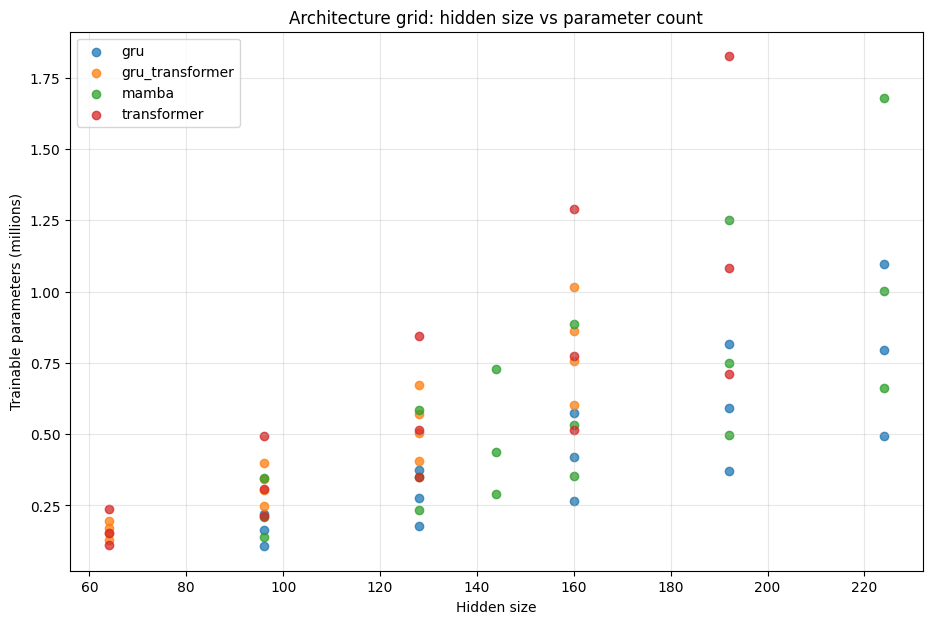

In [12]:
plt.figure(figsize=(11, 7))

for model_name, subdf in grid_df.groupby("model_name"):
    plt.scatter(
        subdf["hidden_size"],
        subdf["trainable_params_m"],
        label=model_name,
        alpha=0.75,
    )

plt.xlabel("Hidden size")
plt.ylabel("Trainable parameters (millions)")
plt.title("Architecture grid: hidden size vs parameter count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

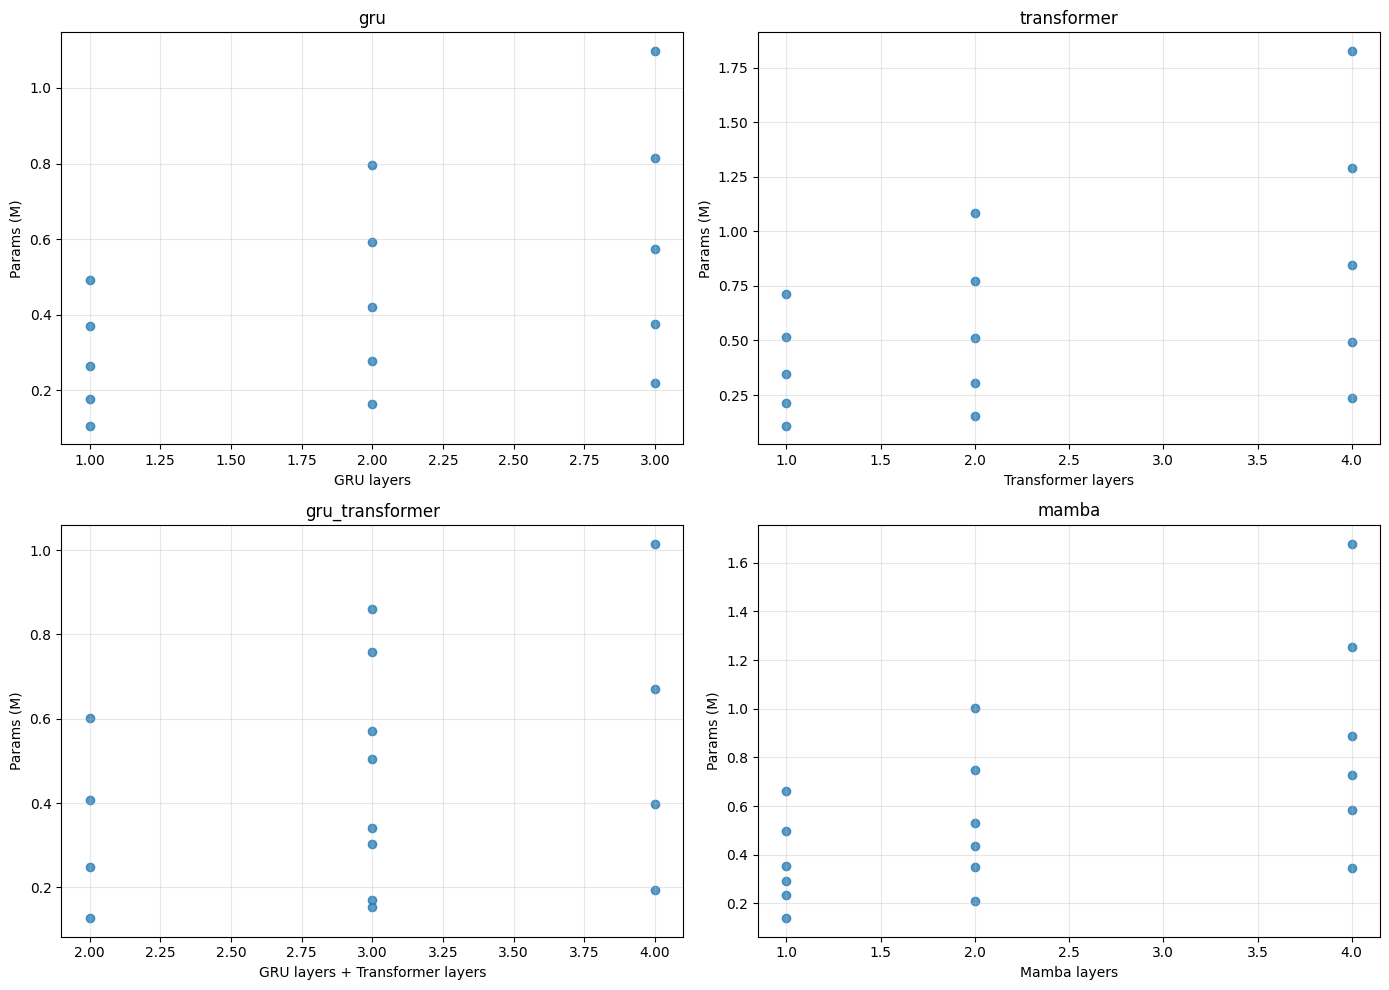

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

families = ["gru", "transformer", "gru_transformer", "mamba"]

for ax, family in zip(axes, families):
    subdf = grid_df[grid_df["model_name"] == family].copy()

    if family == "gru":
        x = subdf["gru_layers"]
    elif family == "transformer":
        x = subdf["transformer_layers"]
    elif family == "gru_transformer":
        # encode pair as text later; use total depth for scatter
        x = subdf["gru_layers"] + subdf["transformer_layers"]
    elif family == "mamba":
        x = subdf["mamba_layers"]

    ax.scatter(x, subdf["trainable_params_m"], alpha=0.75)
    ax.set_title(family)
    ax.set_ylabel("Params (M)")
    ax.grid(True, alpha=0.3)

    if family == "gru":
        ax.set_xlabel("GRU layers")
    elif family == "transformer":
        ax.set_xlabel("Transformer layers")
    elif family == "gru_transformer":
        ax.set_xlabel("GRU layers + Transformer layers")
    elif family == "mamba":
        ax.set_xlabel("Mamba layers")

plt.tight_layout()
plt.show()

In [14]:
TARGET_BUDGETS = [150_000, 300_000, 600_000]
TOLERANCE = 0.10   # within ±10%

budget_matches = []

for budget in TARGET_BUDGETS:
    for _, row in grid_df.iterrows():
        rel_gap = abs(row["trainable_params"] - budget) / budget
        if rel_gap <= TOLERANCE:
            out = row.to_dict()
            out["target_budget"] = budget
            out["rel_gap"] = rel_gap
            budget_matches.append(out)

budget_df = pd.DataFrame(budget_matches)

if len(budget_df) == 0:
    print("No configs matched the requested budgets within tolerance.")
else:
    budget_df = budget_df.sort_values(
        ["target_budget", "model_name", "rel_gap", "trainable_params"]
    ).reset_index(drop=True)
    display(budget_df.head(50))

,model_name,fc_hidden_ratio,fc_dropout,hidden_size,gru_layers,rnn_dropout,trainable_params,trainable_params_m,depth_repr,transformer_layers,transformer_heads,transformer_ff_ratio,transformer_dropout,mamba_layers,mamba_d_state,mamba_d_conv,mamba_expand,mamba_dropout,target_budget,rel_gap
0,gru,1.75,0.2,96,2.0,0.2,162669,0.162669,gru=2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150000,0.084460
1,gru_transformer,1.75,0.2,64,2.0,0.2,152509,0.152509,"gru=2,tr=1",1.0,4.0,3.0,0.1,NaN,NaN,NaN,NaN,NaN,150000,0.016727
2,mamba,1.75,0.2,96,NaN,NaN,139821,0.139821,mamba=1,NaN,NaN,NaN,NaN,1.0,16.0,4.0,2.0,0.15,150000,0.067860
3,transformer,1.75,0.2,64,NaN,NaN,152317,0.152317,tr=2,2.0,4.0,3.0,0.1,NaN,NaN,NaN,NaN,NaN,150000,0.015447
4,gru,1.75,0.2,128,2.0,0.2,276253,0.276253,gru=2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,300000,0.079157
5,gru_transformer,1.75,0.2,96,2.0,0.2,303981,0.303981,"gru=2,tr=1",1.0,4.0,3.0,0.1,NaN,NaN,NaN,NaN,NaN,300000,0.013270
6,mamba,1.75,0.2,144,NaN,NaN,290901,0.290901,mamba=1,NaN,NaN,NaN,NaN,1.0,16.0,4.0,2.0,0.15,300000,0.030330
7,transformer,1.75,0.2,96,NaN,NaN,306765,0.306765,tr=2,2.0,4.0,3.0,0.1,NaN,NaN,NaN,NaN,NaN,300000,0.022550
8,gru,1.75,0.2,192,2.0,0.2,592509,0.592509,gru=2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,600000,0.012485
9,gru,1.75,0.2,160,3.0,0.2,574093,0.574093,gru=3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,600000,0.043178


In [15]:
if len(budget_df) > 0:
    idx = (
        budget_df.groupby(["target_budget", "model_name"])["rel_gap"]
        .idxmin()
        .values
    )

    best_budget_matches = budget_df.loc[idx].sort_values(
        ["target_budget", "model_name"]
    ).reset_index(drop=True)

    cols = [
        "target_budget",
        "model_name",
        "hidden_size",
        "trainable_params",
        "trainable_params_m",
        "rel_gap",
        "depth_repr",
        "fc_hidden_ratio",
    ]

    # add optional columns if present
    optional_cols = [
        "gru_layers",
        "transformer_layers",
        "mamba_layers",
        "transformer_ff_ratio",
        "transformer_heads",
        "mamba_expand",
    ]
    cols += [c for c in optional_cols if c in best_budget_matches.columns]

    display(best_budget_matches[cols])

,target_budget,model_name,hidden_size,trainable_params,trainable_params_m,rel_gap,depth_repr,fc_hidden_ratio,gru_layers,transformer_layers,mamba_layers,transformer_ff_ratio,transformer_heads,mamba_expand
0,150000,gru,96,162669,0.162669,0.084460,gru=2,1.75,2.0,NaN,NaN,NaN,NaN,NaN
1,150000,gru_transformer,64,152509,0.152509,0.016727,"gru=2,tr=1",1.75,2.0,1.0,NaN,3.0,4.0,NaN
2,150000,mamba,96,139821,0.139821,0.067860,mamba=1,1.75,NaN,NaN,1.0,NaN,NaN,2.0
3,150000,transformer,64,152317,0.152317,0.015447,tr=2,1.75,NaN,2.0,NaN,3.0,4.0,NaN
4,300000,gru,128,276253,0.276253,0.079157,gru=2,1.75,2.0,NaN,NaN,NaN,NaN,NaN
5,300000,gru_transformer,96,303981,0.303981,0.013270,"gru=2,tr=1",1.75,2.0,1.0,NaN,3.0,4.0,NaN
6,300000,mamba,144,290901,0.290901,0.030330,mamba=1,1.75,NaN,NaN,1.0,NaN,NaN,2.0
7,300000,transformer,96,306765,0.306765,0.022550,tr=2,1.75,NaN,2.0,NaN,3.0,4.0,NaN
8,600000,gru,192,592509,0.592509,0.012485,gru=2,1.75,2.0,NaN,NaN,NaN,NaN,NaN
9,600000,gru_transformer,160,602893,0.602893,0.004822,"gru=1,tr=1",1.75,1.0,1.0,NaN,3.0,4.0,NaN


In [16]:
gru_df = grid_df[grid_df["model_name"] == "gru"].copy()
if len(gru_df) > 0:
    pivot = gru_df.pivot_table(
        index="gru_layers",
        columns="hidden_size",
        values="trainable_params_m",
        aggfunc="mean",
    )
    display(pivot.style.format("{:.3f}"))

hidden_size,96,128,160,192,224
gru_layers,,,,,
1.000000,0.107,0.177,0.265,0.370,0.493
2.000000,0.163,0.276,0.420,0.593,0.795
3.000000,0.219,0.375,0.574,0.815,1.098


In [17]:
tr_df = grid_df[grid_df["model_name"] == "transformer"].copy()
if len(tr_df) > 0:
    pivot = tr_df.pivot_table(
        index="transformer_layers",
        columns="hidden_size",
        values="trainable_params_m",
        aggfunc="mean",
    )
    display(pivot.style.format("{:.3f}"))

hidden_size,64,96,128,160,192
transformer_layers,,,,,
1.000000,0.111,0.213,0.348,0.514,0.713
2.000000,0.152,0.307,0.513,0.772,1.083
4.000000,0.236,0.493,0.844,1.288,1.825


In [18]:
grutr_df = grid_df[grid_df["model_name"] == "gru_transformer"].copy()
if len(grutr_df) > 0:
    grutr_df["depth_pair"] = (
        "gru=" + grutr_df["gru_layers"].astype(str)
        + ",tr=" + grutr_df["transformer_layers"].astype(str)
    )
    pivot = grutr_df.pivot_table(
        index="depth_pair",
        columns="hidden_size",
        values="trainable_params_m",
        aggfunc="mean",
    )
    display(pivot.style.format("{:.3f}"))

hidden_size,64,96,128,160
depth_pair,,,,
"gru=1.0,tr=1.0",0.128,0.248,0.407,0.603
"gru=1.0,tr=2.0",0.169,0.341,0.572,0.861
"gru=2.0,tr=1.0",0.153,0.304,0.506,0.757
"gru=2.0,tr=2.0",0.194,0.397,0.671,1.015


In [19]:
mamba_df = grid_df[grid_df["model_name"] == "mamba"].copy()
if len(mamba_df) > 0:
    pivot = mamba_df.pivot_table(
        index="mamba_layers",
        columns="hidden_size",
        values="trainable_params_m",
        aggfunc="mean",
    )
    display(pivot.style.format("{:.3f}"))

hidden_size,96,128,144,160,192,224
mamba_layers,,,,,,
1.000000,0.140,0.235,0.291,0.353,0.496,0.663
2.000000,0.208,0.351,0.437,0.531,0.748,1.002
4.000000,0.345,0.585,0.728,0.887,1.252,1.679


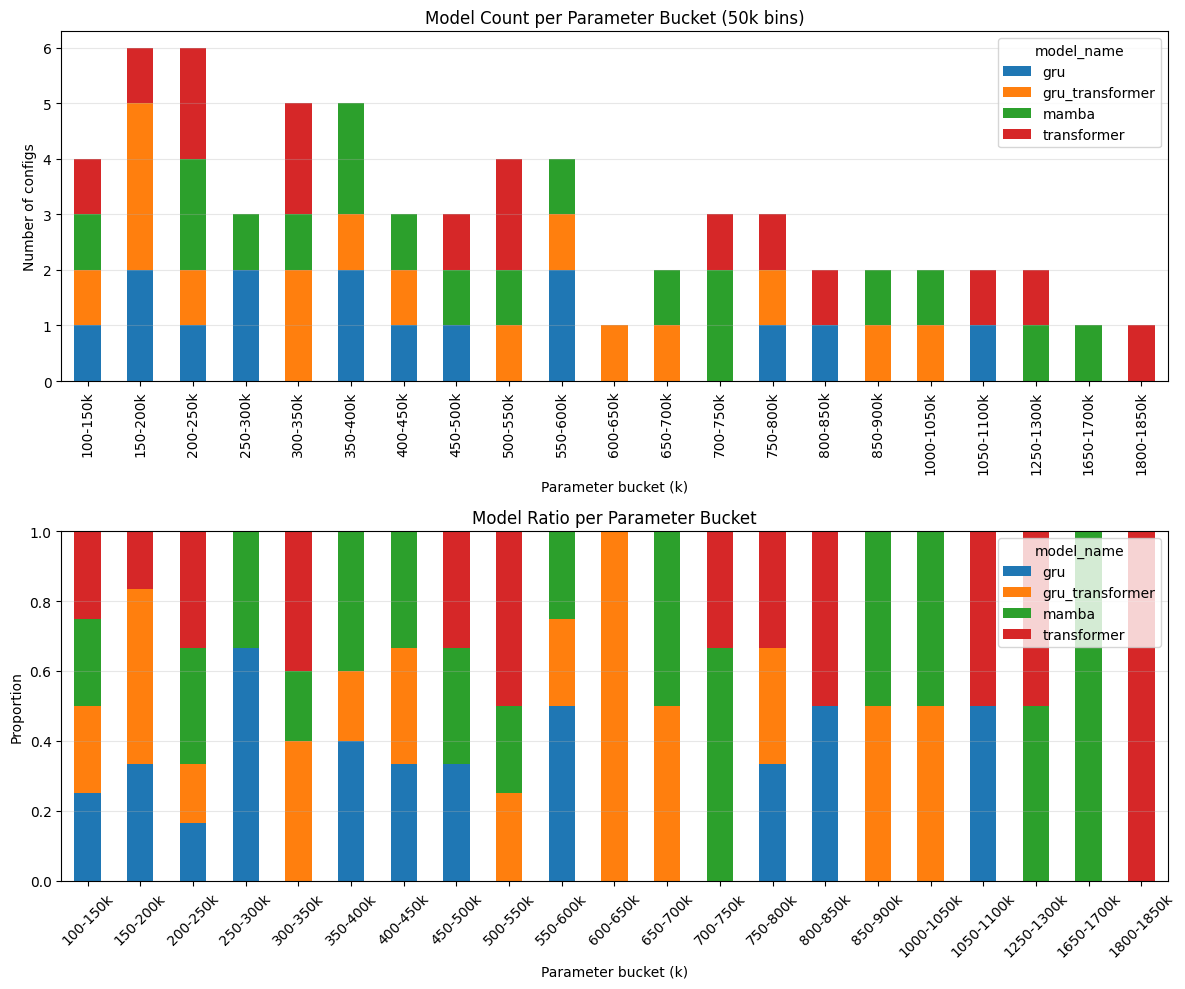

In [20]:
BIN_SIZE = 50_000  # 50k per bucket

df = grid_df.copy()

# Compute bucket index
df["param_bucket"] = (df["trainable_params"] // BIN_SIZE).astype(int)

# Create readable labels like "0-50k", "50k-100k", ...
def bucket_label(idx):
    start = idx * BIN_SIZE
    end = start + BIN_SIZE
    return f"{start//1000}-{end//1000}k"

df["bucket_label"] = df["param_bucket"].apply(bucket_label)

# Sort buckets properly
bucket_order = sorted(df["param_bucket"].unique())
bucket_labels = [bucket_label(i) for i in bucket_order]

# ----- Count table -----
count_table = (
    df.groupby(["bucket_label", "model_name"])
      .size()
      .unstack(fill_value=0)
      .reindex(bucket_labels)
)

# ----- Ratio table (normalized within each bucket) -----
ratio_table = count_table.div(count_table.sum(axis=1), axis=0).fillna(0)

# ----- Plot -----
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- (1) Raw counts ---
count_table.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
)

axes[0].set_title("Model Count per Parameter Bucket (50k bins)")
axes[0].set_ylabel("Number of configs")
axes[0].set_xlabel("Parameter bucket (k)")
axes[0].grid(axis="y", alpha=0.3)

# --- (2) Ratios ---
ratio_table.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
)

axes[1].set_title("Model Ratio per Parameter Bucket")
axes[1].set_ylabel("Proportion")
axes[1].set_xlabel("Parameter bucket (k)")
axes[1].grid(axis="y", alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== Config counts (200K–500K) ===
            gru:    7 ( 28.0%)
gru_transformer:    5 ( 20.0%)
          mamba:    8 ( 32.0%)
    transformer:    5 ( 20.0%)
          TOTAL:   25


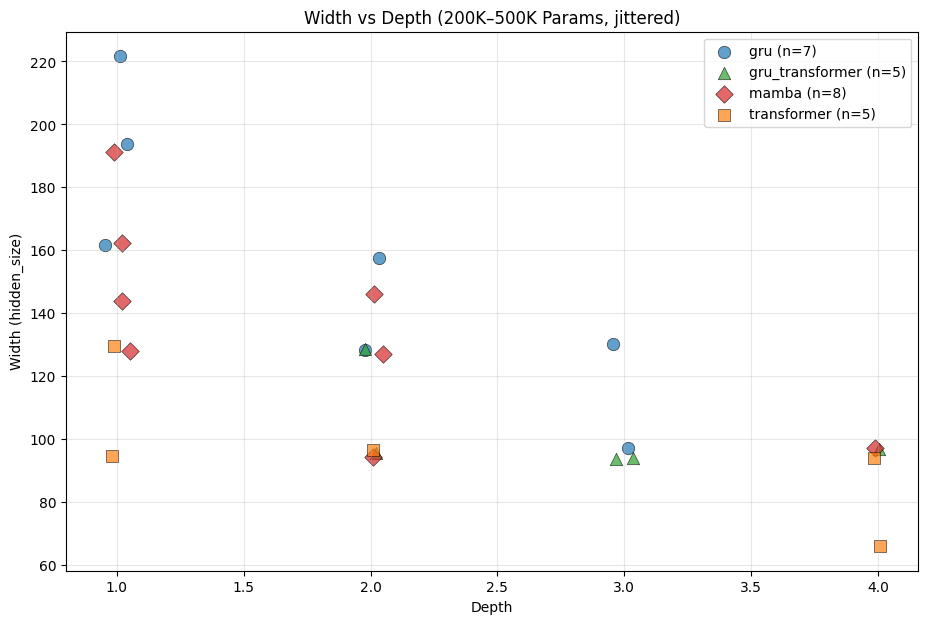

In [21]:
# ----- Config -----
MIN_PARAMS = 200_000
MAX_PARAMS = 500_000
JITTER = 0.05  # small jitter to separate overlapping points

plot_df = grid_df[
    (grid_df["trainable_params"] >= MIN_PARAMS) &
    (grid_df["trainable_params"] <= MAX_PARAMS)
].copy()

# ----- Depth mapping -----
def get_depth_value(row):
    if row["model_name"] == "gru":
        return row["gru_layers"]
    elif row["model_name"] == "transformer":
        return row["transformer_layers"]
    elif row["model_name"] == "gru_transformer":
        return row["gru_layers"] + row["transformer_layers"]
    elif row["model_name"] == "mamba":
        return row["mamba_layers"]

plot_df["depth_value"] = plot_df.apply(get_depth_value, axis=1)
plot_df["width_value"] = plot_df["hidden_size"]

# ----- Count summary -----
count_series = plot_df["model_name"].value_counts().sort_index()
total = count_series.sum()

print("=== Config counts (200K–500K) ===")
for model, count in count_series.items():
    pct = 100 * count / total
    print(f"{model:>15}: {count:4d} ({pct:5.1f}%)")

print(f"{'TOTAL':>15}: {total:4d}")

# ----- Styling -----
COLORS = {
    "gru": "#1f77b4",
    "transformer": "#ff7f0e",
    "gru_transformer": "#2ca02c",
    "mamba": "#d62728",
}

MARKERS = {
    "gru": "o",              # circle
    "transformer": "s",      # square
    "gru_transformer": "^",  # triangle
    "mamba": "D",            # diamond
}

# ----- Plot -----
plt.figure(figsize=(11, 7))

rng = np.random.default_rng(0)

for model_name, subdf in plot_df.groupby("model_name"):
    x = subdf["depth_value"].values.astype(float)
    y = subdf["width_value"].values.astype(float)

    # Add jitter to reduce overlap
    x_jitter = x + rng.uniform(-JITTER, JITTER, size=len(x))
    y_jitter = y + rng.uniform(-JITTER * 50, JITTER * 50, size=len(y))  # scale for width

    plt.scatter(
        x_jitter,
        y_jitter,
        label=f"{model_name} (n={len(subdf)})",
        color=COLORS[model_name],
        marker=MARKERS[model_name],
        alpha=0.7,
        s=80,
        edgecolors="black",
        linewidths=0.5,
    )

plt.xlabel("Depth")
plt.ylabel("Width (hidden_size)")
plt.title("Width vs Depth (200K–500K Params, jittered)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [24]:
# ----- Selection rule -----
MIN_PARAMS = 200_000
MAX_PARAMS = 500_000

# ----- Output file -----
OUTPUT_PATH = repo_root / "model_configs" / "deephit_configs_param_200k_500k_v1.jsonl"

# ----- Keys that downstream model-building/training should keep -----
ESSENTIAL_KEYS = [
    # shared
    "model_name",
    "hidden_size",
    "fc_hidden",
    "fc_hidden_ratio",
    "fc_dropout",

    # derived / useful for bookkeeping
    "trainable_params",
    "trainable_params_m",

    # GRU
    "gru_layers",
    "rnn_dropout",

    # Transformer
    "transformer_layers",
    "transformer_heads",
    "transformer_ff_ratio",
    "transformer_dropout",

    # GRU + Transformer uses both GRU and Transformer keys above

    # Mamba
    "mamba_layers",
    "mamba_d_state",
    "mamba_d_conv",
    "mamba_expand",
    "mamba_dropout",
]

# ----- Helper functions -----
def is_missing_value(x):
    try:
        # handles pandas/numpy NaN without importing pandas explicitly
        return x != x
    except Exception:
        return False

def clean_record_values(record: dict) -> dict:
    """Drop missing values and convert numpy scalars to Python scalars when possible."""
    cleaned = {}
    for k, v in record.items():
        if is_missing_value(v):
            continue
        if hasattr(v, "item"):  # numpy scalar -> Python scalar
            try:
                v = v.item()
            except Exception:
                pass
        cleaned[k] = v
    return cleaned

def normalize_for_id(record: dict) -> dict:
    """
    Keep only stable config-defining fields for the config_id.
    Excludes metadata and display-only fields.
    """
    excluded = {
        "config_id",
        "created_at",
        "selection_min_params",
        "selection_max_params",
        "output_path",
        "depth_repr",
        "width_value",
        "depth_value",
        "bucket_label",
        "param_bucket",
    }
    return {k: record[k] for k in sorted(record.keys()) if k not in excluded}

def make_config_id(record: dict) -> str:
    payload = json.dumps(normalize_for_id(record), sort_keys=True)
    return hashlib.md5(payload.encode("utf-8")).hexdigest()[:12]

def infer_depth_repr(record: dict) -> str:
    model_name = record["model_name"]
    if model_name == "gru":
        return f"gru={record.get('gru_layers')}"
    elif model_name == "transformer":
        return f"tr={record.get('transformer_layers')}"
    elif model_name == "gru_transformer":
        return f"gru={record.get('gru_layers')},tr={record.get('transformer_layers')}"
    elif model_name == "mamba":
        return f"mamba={record.get('mamba_layers')}"
    return "unknown"

# ----- Filter selected rows -----
selected_df = grid_df[
    (grid_df["trainable_params"] >= MIN_PARAMS) &
    (grid_df["trainable_params"] <= MAX_PARAMS)
].copy()

if len(selected_df) == 0:
    raise ValueError(
        f"No configs found in parameter range [{MIN_PARAMS}, {MAX_PARAMS}]."
    )

# ----- Build records -----
created_at = datetime.now(timezone.utc).isoformat()

records = []
for row in selected_df.to_dict(orient="records"):
    # Keep only fields that matter downstream
    base = {k: row[k] for k in ESSENTIAL_KEYS if k in row}
    base = clean_record_values(base)

    # Add useful metadata
    base["selection_min_params"] = MIN_PARAMS
    base["selection_max_params"] = MAX_PARAMS
    base["created_at"] = created_at
    base["depth_repr"] = infer_depth_repr(base)

    # Stable ID for checkpoints / W&B / filenames
    base["config_id"] = make_config_id(base)

    records.append(base)

# ----- Deduplicate in case the same config appears twice -----
deduped = {}
for record in records:
    deduped[record["config_id"]] = record
records = list(deduped.values())

# ----- Sort for readability -----
records = sorted(
    records,
    key=lambda r: (
        r["model_name"],
        r.get("trainable_params", 0),
        r.get("hidden_size", 0),
        r.get("gru_layers", -1),
        r.get("transformer_layers", -1),
        r.get("mamba_layers", -1),
    ),
)

# ----- Write JSONL -----
with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    for record in records:
        f.write(json.dumps(record) + "\n")

# ----- Console summary -----
print(f"Saved {len(records)} configs to: {OUTPUT_PATH.resolve()}")
print(f"Parameter range: [{MIN_PARAMS:,}, {MAX_PARAMS:,}]")
print()

# Per-model counts
counts = {}
for r in records:
    counts[r["model_name"]] = counts.get(r["model_name"], 0) + 1

print("Counts by model type:")
for model_name in sorted(counts.keys()):
    print(f"  {model_name:>15}: {counts[model_name]}")

print()
print("First 3 records:")
for r in records[:3]:
    print(json.dumps(r, indent=2))

Saved 25 configs to: /ocean/projects/cis260122p/gfeng/lob-deep-survival-analysis/model_configs/deephit_configs_param_200k_500k_v1.jsonl
Parameter range: [200,000, 500,000]

Counts by model type:
              gru: 7
  gru_transformer: 5
            mamba: 8
      transformer: 5

First 3 records:
{
  "model_name": "gru",
  "hidden_size": 96,
  "fc_hidden_ratio": 1.75,
  "fc_dropout": 0.2,
  "trainable_params": 218541,
  "trainable_params_m": 0.218541,
  "gru_layers": 3.0,
  "rnn_dropout": 0.2,
  "selection_min_params": 200000,
  "selection_max_params": 500000,
  "created_at": "2026-04-18T21:51:48.548427+00:00",
  "depth_repr": "gru=3.0",
  "config_id": "3ae621735073"
}
{
  "model_name": "gru",
  "hidden_size": 160,
  "fc_hidden_ratio": 1.75,
  "fc_dropout": 0.2,
  "trainable_params": 264973,
  "trainable_params_m": 0.264973,
  "gru_layers": 1.0,
  "rnn_dropout": 0.2,
  "selection_min_params": 200000,
  "selection_max_params": 500000,
  "created_at": "2026-04-18T21:51:48.548427+00:00",
 